Dimensiones del dataset: 10000 filas y 10 columnas.

Estadísticas Descriptivas
                count          mean           std   min         25%  \
dst_port      10000.0  5.272964e+03  7.348396e+03  21.0     53.0000   
bytes_sent    10000.0  2.815289e+07  3.115671e+08  15.0   5544.0000   
bytes_recv    10000.0  4.124360e+05  1.964278e+06   0.0  13288.0000   
duration_sec  10000.0  4.471547e+02  4.530488e+03   0.0      8.5075   
packets       10000.0  1.605501e+04  1.672859e+05   1.0      5.0000   

                    50%         75%           max  
dst_port       3389.000    8080.000  6.546000e+04  
bytes_sent    22339.000   94781.750  4.987050e+09  
bytes_recv    55290.500  221325.750  8.155783e+07  
duration_sec     21.435      44.145  8.302815e+04  
packets          24.000     110.000  2.939448e+06  

Valores nulos encontrados: 0

¡Feature Engineering completado! Se añadieron 'ratio_bytes' y 'bytes_por_segundo'.


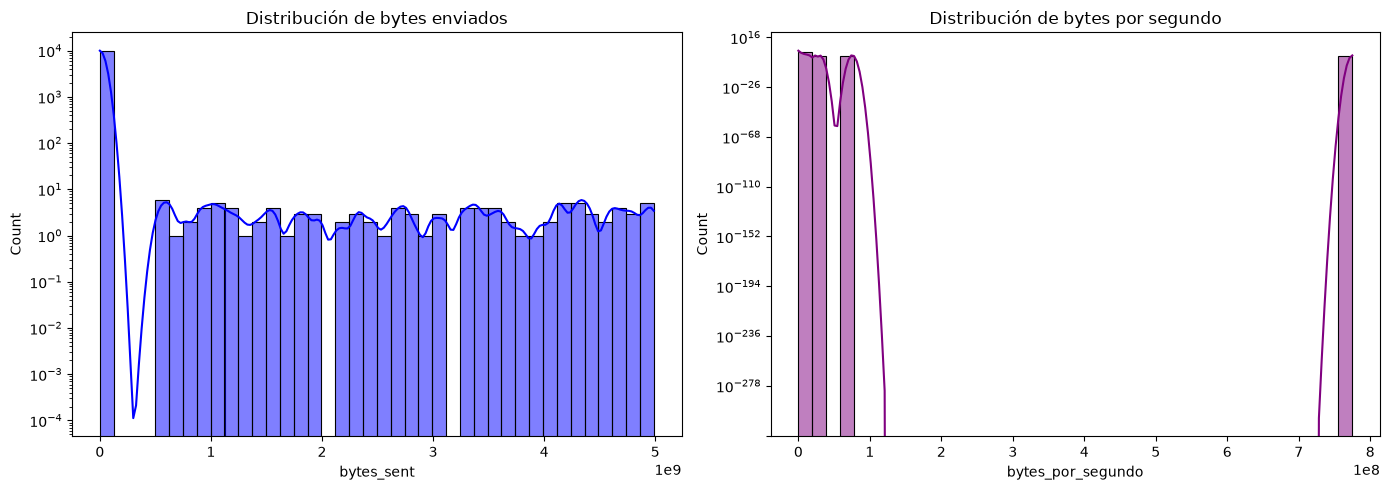

Características seleccionadas para el modelo
['dst_port', 'bytes_sent', 'bytes_recv', 'duration_sec', 'packets', 'ratio_bytes', 'bytes_por_segundo']

Matriz X_scaled lista para entrenamiento. Forma: (10000, 7)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Cargar el datasett
try:
    df = pd.read_csv('lab3/network_traffic.csv')
    print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.\n")
except FileNotFoundError:
    df = pd.read_csv('network_traffic.csv')

    print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.\n")

print("Estadísticas Descriptivas")
print(df.describe().T)

nulos = df.isnull().sum().sum()
print(f"\nValores nulos encontrados: {nulos}")
if nulos > 0:
    df = df.dropna()
    print("Valores nulos eliminados.")

df['ratio_bytes'] = df['bytes_sent'] / (df['bytes_recv'] + 1)

df['bytes_por_segundo'] = (df['bytes_sent'] + df['bytes_recv']) / (df['duration_sec'] + 0.001)

print("\n¡Feature Engineering completado! Se añadieron 'ratio_bytes' y 'bytes_por_segundo'.")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['bytes_sent'], kde=True, bins=40, color='blue')
plt.title('Distribución de bytes enviados')
plt.yscale('log') # Escala logarítmica para apreciar mejor los extremos/anomalías

plt.subplot(1, 2, 2)
sns.histplot(df['bytes_por_segundo'], kde=True, bins=40, color='purple')
plt.title('Distribución de bytes por segundo')
plt.yscale('log')

plt.tight_layout()
plt.show()

features_cols = ['dst_port', 'bytes_sent', 'bytes_recv', 'duration_sec', 'packets', 'ratio_bytes', 'bytes_por_segundo']
X = df[features_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Características seleccionadas para el modelo")
print(features_cols)
print(f"\nMatriz X_scaled lista para entrenamiento. Forma: {X_scaled.shape}")

================ REPORTE DE CLASIFICACIÓN ================
              precision    recall  f1-score   support

     anomaly       0.64      0.64      0.64       500
      normal       0.98      0.98      0.98      9500

    accuracy                           0.96     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.96      0.96      0.96     10000




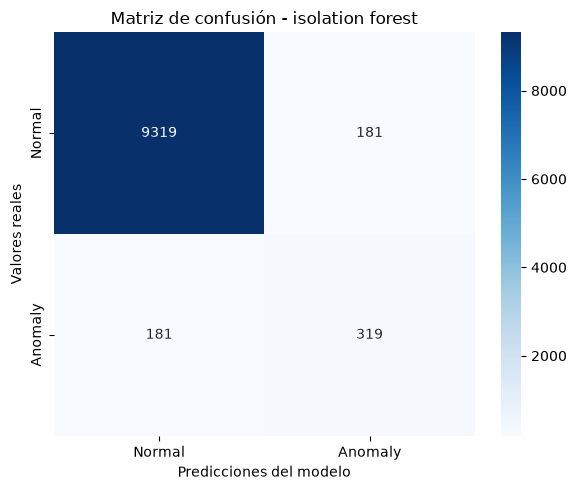

In [6]:
#Entrenamiento del modelo
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

iso_forest = IsolationForest(contamination=0.05, n_estimators=100, random_state=42)
iso_forest.fit(X_scaled)

df['pred_code'] = iso_forest.predict(X_scaled)

df['pred_label'] = df['pred_code'].map({1: 'normal', -1: 'anomaly'})

print("================ REPORTE DE CLASIFICACIÓN ================")
print(classification_report(df['label'], df['pred_label']))
print("==========================================================\n")

cm = confusion_matrix(df['label'], df['pred_label'], labels=['normal', 'anomaly'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Anomaly'], 
            yticklabels=['Normal', 'Anomaly'])
plt.title('Matriz de confusión - isolation forest')
plt.ylabel('Valores reales')
plt.xlabel('Predicciones del modelo')
plt.tight_layout()
plt.show()

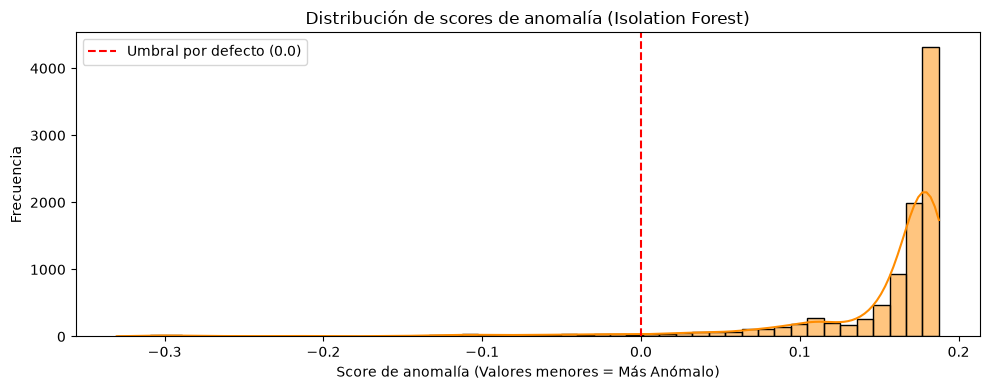

==================== top 10 registros mas anomalos ====================
 dst_port  bytes_sent  bytes_recv  duration_sec  packets   ratio_bytes  bytes_por_segundo  anomaly_score   label
     8080  4602183026       43276        682.60  2052006 106342.468886       6.742191e+06      -0.330125 anomaly
      443  4706448909        9058       2778.48  2914444 519532.940612       1.693896e+06      -0.325075 anomaly
       80  4235188534        9595       1943.41  2666007 441349.367862       2.179260e+06      -0.323957 anomaly
     8080  2739832080       11140        342.89  1882321 245923.353379       7.990420e+06      -0.321725 anomaly
       53  3385524170       18133        451.40  2532734 186694.836771       7.500077e+06      -0.320143 anomaly
     8080  4313654623       13352       2004.06  2182785 323047.601513       2.152463e+06      -0.320055 anomaly
       80  4696305972       21229        383.65  1693674 221210.832407       1.224114e+07      -0.320055 anomaly
     8080  4155915523   

In [11]:
# Interpretación y umbral dinámico
df['anomaly_score'] = iso_forest.decision_function(X_scaled)

plt.figure(figsize=(10, 4))
sns.histplot(df['anomaly_score'], bins=50, kde=True, color='darkorange')
plt.axvline(x=0, color='red', linestyle='--', label='Umbral por defecto (0.0)')
plt.title('Distribución de scores de anomalía (Isolation Forest)')
plt.xlabel('Score de anomalía (Valores menores = Más Anómalo)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

top_10_anomalies = df.sort_values(by='anomaly_score', ascending=True).head(10)

print("==================== top 10 registros mas anomalos ====================")
columnas_analisis = ['dst_port', 'bytes_sent', 'bytes_recv', 'duration_sec', 'packets', 'ratio_bytes', 'bytes_por_segundo', 'anomaly_score', 'label']
print(top_10_anomalies[columnas_analisis].to_string(index=False))
print("=======================================================================\n")

print("Explicacion .-")
print("Los 10 registros listados arriba presentan los 'anomaly_score' más bajos del sistema. Esto se debe a desviaciones extremas en las variables derivadas que creamos en la Tarea 3.1")
print("1.- Volúmenes atípicos de transferencia (bytes_sent o bytes_recv críticamente elevados).")
print("2.- Conexiones con una tasa de 'bytes_por_segundo' masiva en intervalos de tiempo muy cortos.")
print("3.- Puertos de destino inusuales actuando como sumideros de datos masivos.")

In [15]:
# Exportación del modelo 

import joblib

joblib.dump(iso_forest, 'modelo_anomalias.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("==========================================================")
print(" Modelo y Escalador exportados correctamente ")
print("==========================================================")
print(" Archivos generados ")
print(" modelo_anomalias.pkl (Modelo isolation forest entrenado)")
print(" scaler.pkl           (Configuración del standardScaler)")
print("==========================================================")

 Modelo y Escalador exportados correctamente 
 Archivos generados 
 modelo_anomalias.pkl (Modelo isolation forest entrenado)
 scaler.pkl           (Configuración del standardScaler)
